# Fuel Efficiency Analysis for Transport Operations

## Project Overview

This project analyzes fuel consumption, fleet performance, and fuel efficiency metrics using operational transportation data collected from a bulk mineral transportation fleet.

The objective is to identify operational trends, evaluate fuel efficiency performance, compare expected versus actual fuel consumption, and identify high-performing vehicles within the fleet.

## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Load Data

In [5]:
archivo = "fuel_efficiency_portfolio_v2.xlsm"

xls = pd.ExcelFile(archivo)

xls.sheet_names

['ENERO',
 'RENDIMIENTO-ENERO',
 'FEBRERO',
 'RENDIMIENTO-FEBRERO',
 'MARZO',
 'RENDIMIENTO-MARZO',
 'ABRIL',
 'RENDIMIENTO-ABRIL',
 'MAYO',
 'RENDIMIENTO-MAYO',
 'JUNIO',
 'RENDIMIENTO-JUNIO',
 'JULIO',
 'RENDIMIENTO-JULIO',
 'AGOSTO',
 'RENDIMIENTO-AGOSTO',
 'SEPTIEMBRE',
 'RENDIMIENTO-SEPTIEMBRE',
 'OCTUBRE',
 'RENDIMIENTO-OCTUBRE',
 'NOVIEMBRE',
 'RENDIMIENTO-NOVIEMBRE',
 'DICIEMBRE',
 'RENDIMIENTO-DICIEMBRE',
 'RUTAS',
 'ASIGNACIONES',
 'RENDIMIENTO']

## Data Consolidation

In [6]:
meses = [
    'ENERO','FEBRERO','MARZO','ABRIL',
    'MAYO','JUNIO','JULIO','AGOSTO',
    'SEPTIEMBRE','OCTUBRE','NOVIEMBRE','DICIEMBRE'
]

dfs = []

for mes in meses:

    temp = pd.read_excel(
        archivo,
        sheet_name=mes
    )

    temp.columns = temp.columns.str.strip()

    # Renombrar columnas
    temp = temp.rename(columns={
        'NC':'unidad',
        'NC ':'unidad',
        'NC':'unidad',
        'LITROS':'litros',
        'PRECIO DIÉSEL':'precio_diesel',
        'IMPORTE':'importe',
        'RUTAS':'ruta',
        'Distancia Recorrida':'distancia_recorrida',
        'Distancia Cargado':'distancia_cargado',
        '% Cargado':'porcentaje_cargado',
        'Rendimiento Esperado':'rendimiento_esperado',
        'Diésel Esperado':'diesel_esperado',
        'Diferencia Diésel':'diferencia_diesel',
        'Rendimiento Real':'rendimiento_real',
        'OBSERVACIONES':'observaciones',
        'FECHA':'fecha'
    })

    temp['mes'] = mes

    columnas_utiles = [
        'fecha',
        'unidad',
        'litros',
        'precio_diesel',
        'importe',
        'ruta',
        'distancia_recorrida',
        'distancia_cargado',
        'porcentaje_cargado',
        'rendimiento_esperado',
        'diesel_esperado',
        'rendimiento_real',
        'diferencia_diesel',
        'observaciones',
        'mes'
    ]

    temp = temp.reindex(columns=columnas_utiles)

    dfs.append(temp)

df_clean = pd.concat(
    dfs,
    ignore_index=True
)

df_clean.head()

,fecha,unidad,litros,precio_diesel,importe,ruta,distancia_recorrida,distancia_cargado,porcentaje_cargado,rendimiento_esperado,diesel_esperado,rendimiento_real,diferencia_diesel,observaciones,mes
0,2025-01-01 00:00:00,77,867.6244,25.15,21820.75,PAR/MAN/TEC/GTS/PAR,2930.0,1480,0.505119,2.45,NaN,2.311408,NaN,NaN,ENERO
1,2025-01-01 00:00:00,71,904.3624,25.15,22744.71,PAR/MAN/TEC/GTS/PAR,2930.0,1480,0.505119,2.45,NaN,2.246306,NaN,NaN,ENERO
2,2025-01-01 12:00:00,91,753.5247,25.15,18951.15,PAR/MAN/TEC/GTS/PAR,2930.0,1480,0.505119,2.45,NaN,2.540038,NaN,NO ENVIO,ENERO
3,2025-01-01 12:00:00,111,756.8877,25.15,19035.73,PAR/MAN/TEC/GTS/PAR,2930.0,1480,0.505119,2.45,NaN,2.532655,NaN,NaN,ENERO
4,2025-01-01 12:00:00,79,794.4334,25.15,19980,PAR/MAN/TEC/GTS/PAR,2930.0,1480,0.505119,2.45,NaN,2.453043,NaN,NaN,ENERO


In [8]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2635 entries, 0 to 2634
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 2318 non-null   object 
 1   unidad                2318 non-null   object 
 2   litros                2317 non-null   object 
 3   precio_diesel         1700 non-null   object 
 4   importe               1707 non-null   object 
 5   ruta                  1859 non-null   object 
 6   distancia_recorrida   1823 non-null   object 
 7   distancia_cargado     1664 non-null   object 
 8   porcentaje_cargado    1656 non-null   float64
 9   rendimiento_esperado  1664 non-null   object 
 10  diesel_esperado       0 non-null      float64
 11  rendimiento_real      1650 non-null   float64
 12  diferencia_diesel     0 non-null      float64
 13  observaciones         180 non-null    object 
 14  mes                   2635 non-null   str    
dtypes: float64(4), object(10), str(1

## Data Cleaning

In [9]:
# Create a working copy
df_analysis = df_clean.copy()

# Remove rows without key operational fields
df_analysis = df_analysis.dropna(
    subset=['fecha', 'unidad', 'litros', 'ruta']
)

# Identify partial loads
df_analysis['litros_texto'] = df_analysis['litros'].astype(str)
df_analysis['carga_parcial'] = df_analysis['litros_texto'].str.startswith('P_', na=False)

# Exclude partial fuel loads
df_analysis = df_analysis[~df_analysis['carga_parcial']].copy()

# Convert numeric columns
numeric_columns = [
    'litros',
    'precio_diesel',
    'importe',
    'distancia_recorrida',
    'distancia_cargado',
    'porcentaje_cargado',
    'rendimiento_esperado',
    'diesel_esperado',
    'rendimiento_real',
    'diferencia_diesel'
]

for col in numeric_columns:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# Convert date column
df_analysis['fecha'] = pd.to_datetime(df_analysis['fecha'], errors='coerce')

# Remove unrealistic expected efficiency values
df_analysis = df_analysis[
    (df_analysis['rendimiento_esperado'].isna()) |
    (df_analysis['rendimiento_esperado'] <= 10)
].copy()

df_analysis.info()

<class 'pandas.DataFrame'>
Index: 1696 entries, 0 to 2589
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 1695 non-null   datetime64[ns]
 1   unidad                1696 non-null   object        
 2   litros                1695 non-null   float64       
 3   precio_diesel         1648 non-null   float64       
 4   importe               1648 non-null   float64       
 5   ruta                  1696 non-null   object        
 6   distancia_recorrida   1672 non-null   float64       
 7   distancia_cargado     1648 non-null   float64       
 8   porcentaje_cargado    1639 non-null   float64       
 9   rendimiento_esperado  1639 non-null   float64       
 10  diesel_esperado       0 non-null      float64       
 11  rendimiento_real      1638 non-null   float64       
 12  diferencia_diesel     0 non-null      float64       
 13  observaciones         159 non-null

## Data Quality Summary

After cleaning and validation, the final analytical dataset contains 1,696 operational records.

Data preparation included:

- Consolidation of 12 monthly worksheets
- Standardization of column names
- Removal of incomplete records
- Exclusion of partial fuel loads
- Conversion of date and numeric fields
- Validation of fuel efficiency metrics
- Removal of anomalous efficiency values

## Monthly Fuel Consumption

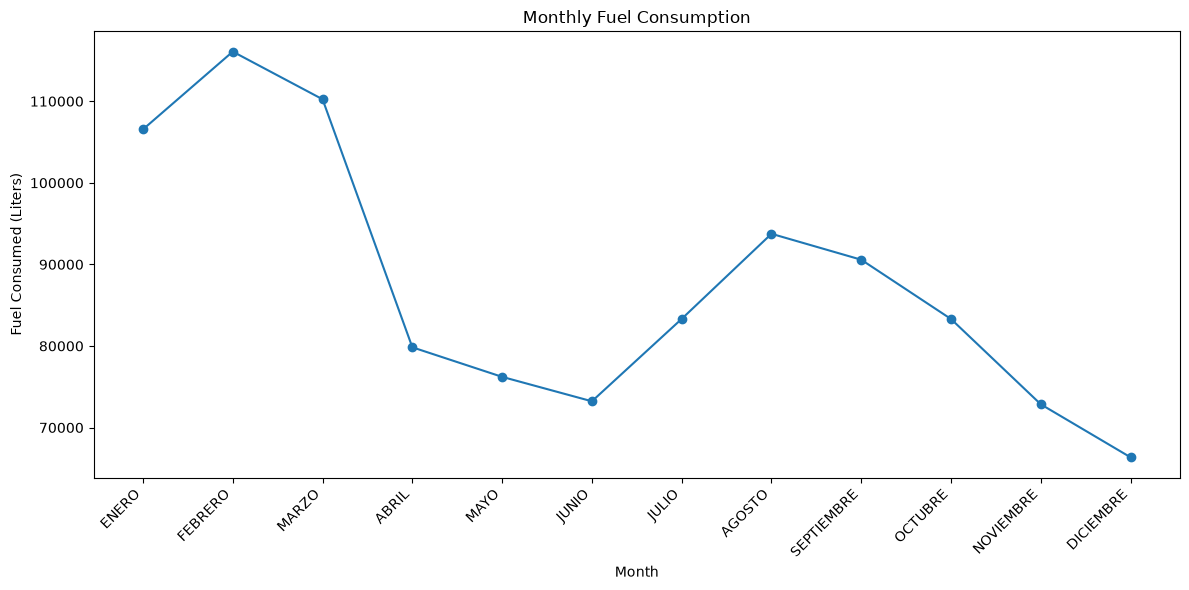

In [12]:
fuel_monthly = (
    df_analysis
    .groupby('mes')['litros']
    .sum()
    .reset_index()
)

orden_meses = [
    'ENERO','FEBRERO','MARZO','ABRIL',
    'MAYO','JUNIO','JULIO','AGOSTO',
    'SEPTIEMBRE','OCTUBRE','NOVIEMBRE','DICIEMBRE'
]

fuel_monthly['mes'] = pd.Categorical(
    fuel_monthly['mes'],
    categories=orden_meses,
    ordered=True
)

fuel_monthly = fuel_monthly.sort_values('mes')

plt.figure(figsize=(12,6))

plt.plot(
    fuel_monthly['mes'],
    fuel_monthly['litros'],
    marker='o'
)

plt.title('Monthly Fuel Consumption')
plt.xlabel('Month')
plt.ylabel('Fuel Consumed (Liters)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(
    'monthly_fuel_consumption.png',
    bbox_inches='tight'
)

plt.show()

### Key Insight

Fuel consumption fluctuated throughout the year and generally reflected changes in operational activity. Monitoring these trends helps identify periods of higher operating costs and supports fuel management decisions.

## Fuel Consumption vs Distance Traveled

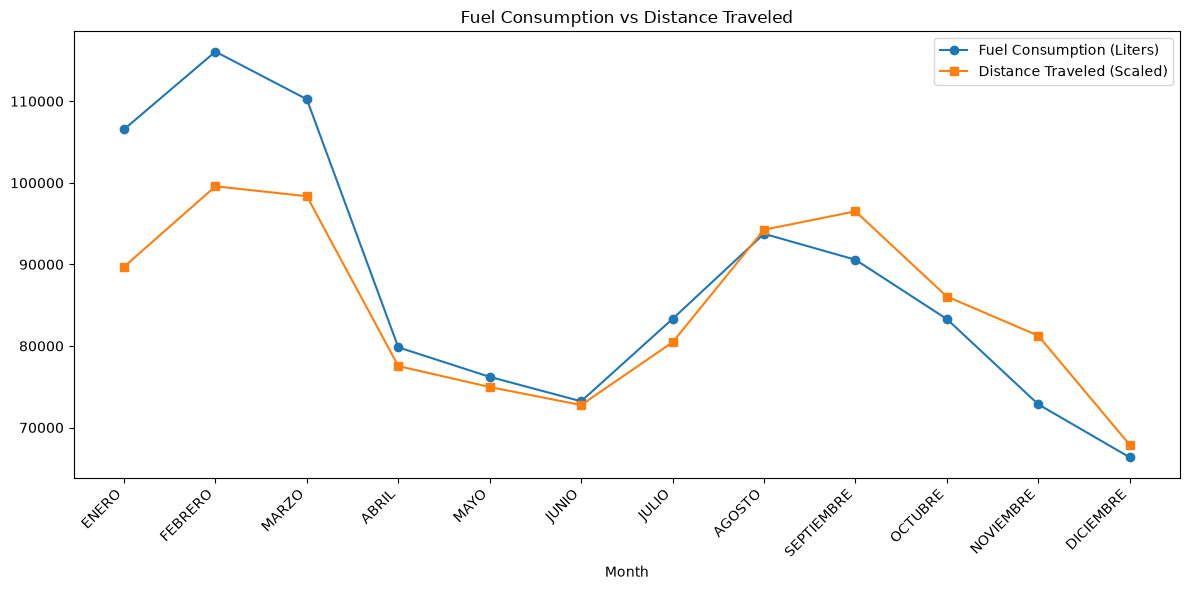

In [14]:
fuel_distance = (
    df_analysis
    .groupby('mes')
    .agg({
        'litros':'sum',
        'distancia_recorrida':'sum'
    })
    .reset_index()
)

fuel_distance['mes'] = pd.Categorical(
    fuel_distance['mes'],
    categories=orden_meses,
    ordered=True
)

fuel_distance = fuel_distance.sort_values('mes')

plt.figure(figsize=(12,6))

plt.plot(
    fuel_distance['mes'],
    fuel_distance['litros'],
    marker='o',
    label='Fuel Consumption (Liters)'
)

plt.plot(
    fuel_distance['mes'],
    fuel_distance['distancia_recorrida'] / 4,
    marker='s',
    label='Distance Traveled (Scaled)'
)

plt.title('Fuel Consumption vs Distance Traveled')
plt.xlabel('Month')

plt.xticks(rotation=45, ha='right')

plt.legend()

plt.tight_layout()

plt.savefig(
    'fuel_consumption_vs_distance.png',
    bbox_inches='tight'
)

plt.show()

### Key Insight

Fuel consumption generally followed operational activity levels throughout the year. Higher fuel consumption periods were associated with increased fleet utilization and distance traveled.

## Expected vs Actual Fuel Efficiency

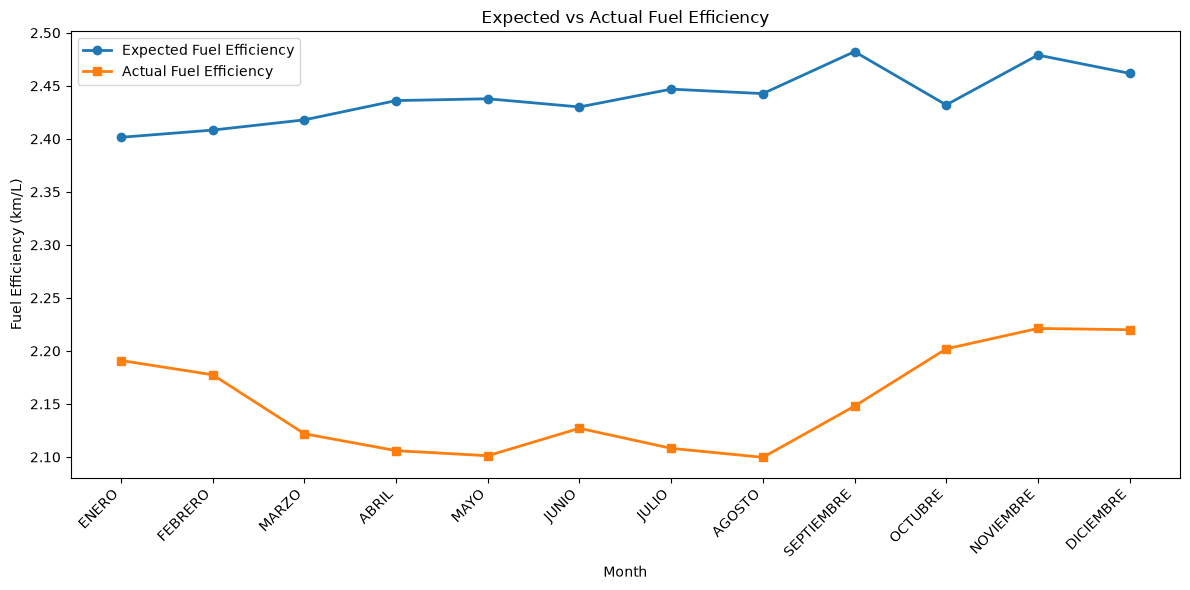

In [15]:
rendimiento_mensual = (
    df_analysis
    .groupby('mes')
    .agg({
        'rendimiento_esperado':'mean',
        'rendimiento_real':'mean'
    })
    .reset_index()
)

rendimiento_mensual['mes'] = pd.Categorical(
    rendimiento_mensual['mes'],
    categories=orden_meses,
    ordered=True
)

rendimiento_mensual = rendimiento_mensual.sort_values('mes')

plt.figure(figsize=(12,6))

plt.plot(
    rendimiento_mensual['mes'],
    rendimiento_mensual['rendimiento_esperado'],
    marker='o',
    linewidth=2,
    label='Expected Fuel Efficiency'
)

plt.plot(
    rendimiento_mensual['mes'],
    rendimiento_mensual['rendimiento_real'],
    marker='s',
    linewidth=2,
    label='Actual Fuel Efficiency'
)

plt.title('Expected vs Actual Fuel Efficiency')
plt.xlabel('Month')
plt.ylabel('Fuel Efficiency (km/L)')

plt.xticks(rotation=45, ha='right')

plt.legend()

plt.tight_layout()

plt.savefig(
    'expected_vs_actual_efficiency.png',
    bbox_inches='tight'
)

plt.show()

### Key Insight

Actual fuel efficiency remained consistently below expected performance throughout the year. The persistent gap between expected and actual efficiency suggests opportunities for operational improvements, maintenance optimization, route planning, and fuel management initiatives.

## Top 10 Vehicles by Fuel Efficiency

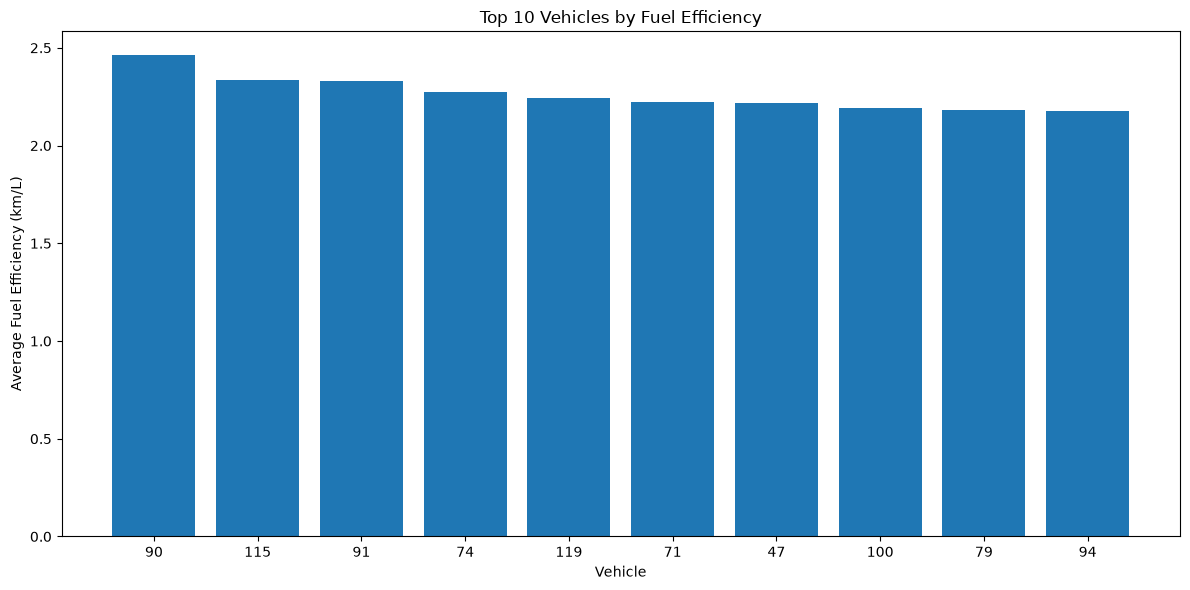

In [16]:
top_unidades = (
    df_analysis
    .groupby('unidad')
    .agg({
        'rendimiento_real':'mean',
        'litros':'sum',
        'distancia_recorrida':'sum'
    })
    .reset_index()
)

# Excluir unidades con poca actividad
top_unidades = top_unidades[
    top_unidades['litros'] > 5000
]

top_unidades = top_unidades.sort_values(
    'rendimiento_real',
    ascending=False
)

top10 = top_unidades.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['unidad'].astype(str),
    top10['rendimiento_real']
)

plt.title('Top 10 Vehicles by Fuel Efficiency')
plt.xlabel('Vehicle')
plt.ylabel('Average Fuel Efficiency (km/L)')

plt.tight_layout()

plt.savefig(
    'top_10_efficient_vehicles.png',
    bbox_inches='tight'
)

plt.show()

### Key Insight

Vehicle-level analysis revealed measurable differences in fuel efficiency across the fleet. Identifying top-performing vehicles provides an opportunity to investigate operational practices, maintenance conditions, and route characteristics that can be replicated across the rest of the fleet.

# Conclusions

This analysis successfully consolidated and evaluated one year of transportation fuel consumption data.

Key findings include:

- Fuel consumption closely follows operational activity.
- Actual fuel efficiency remained below expected performance levels.
- Significant opportunities exist to improve operational efficiency.
- Top-performing vehicles provide valuable benchmarks for fleet optimization.

The project demonstrates how data analytics can support operational decision-making and fuel cost management in transportation operations.